In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

Load and Explore the Dataset

In [ ]:
df = pd.read_csv('FakeNewsData.csv')
print("Dataset shape:", df.shape)
print("\nLabel distribution (0 = Real, 1 = Fake):")
print(df['label'].value_counts(normalize=True) * 100)

# Map: assuming your label is already 'Fake'/'Real' strings
# If it's 0/1 already — skip or adjust
label_map = {'Real': 0, 'Fake': 1}
df['label_num'] = df['label'].map(label_map)

# Use title only (text is useless)
texts = df['title'].astype(str).str.lower()
y = df['label_num'].values


Dataset shape: (4000, 24)

Label distribution (0 = Real, 1 = Fake):
label
Fake    50.65
Real    49.35
Name: proportion, dtype: float64


TF-IDF Vectorization

In [8]:
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(texts).toarray()

print("Feature matrix shape:", X.shape)

Feature matrix shape: (4000, 3000)


Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

Build Neural Network

In [10]:
model = Sequential([
    Dense(128, input_dim=X.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       384,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,449 (1.50 MB)

 Trainable params: 392,449 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

Train

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4967 - loss: 0.6935 - val_accuracy: 0.5083 - val_loss: 0.6925
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5945 - loss: 0.6876 - val_accuracy: 0.5042 - val_loss: 0.6922
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7228 - loss: 0.6618 - val_accuracy: 0.4979 - val_loss: 0.6931
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8496 - loss: 0.5474 - val_accuracy: 0.5167 - val_loss: 0.6966
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8691 - loss: 0.3390 - val_accuracy: 0.5083 - val_loss: 0.7061
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8687 - loss: 0.2369 - val_accuracy: 0.4958 - val_loss: 0.7201
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8801 - loss: 0.2046 - val_accuracy: 0.5042 - val_loss: 0.7244
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8801 - loss: 0.1920 - val_accuracy: 0.5021 - val_lo

Plot learning curves

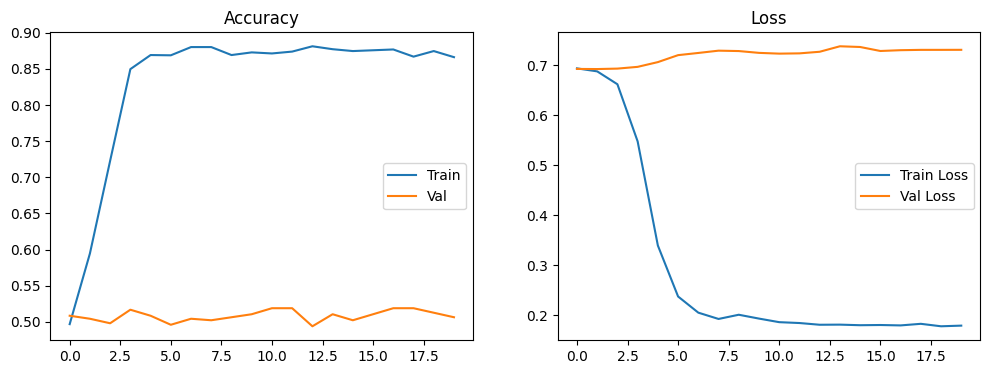

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

Evaluate

In [14]:
from sklearn.metrics import classification_report

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))


Test Accuracy: 0.5063 (50.63%)
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

        Real       0.50      0.41      0.45       395
        Fake       0.51      0.60      0.55       405

    accuracy                           0.51       800
   macro avg       0.51      0.51      0.50       800
weighted avg       0.51      0.51      0.50       800



Manual Test Function

In [15]:
def predict_headline(headline):
    vec = vectorizer.transform([headline.lower()]).toarray()
    prob = model.predict(vec, verbose=0)[0][0]
    label = "Fake News" if prob > 0.5 else "Real News"
    conf = max(prob, 1-prob)
    print(f'"{headline}" → {label} (confidence {conf:.3f})')

Examples

In [16]:
predict_headline("Scientists discover a new planet similar to Earth.")
predict_headline("Aliens have landed in New York and taken control of the city.")
predict_headline("Scientists confirm water on Mars.")
predict_headline("Secret government project creates invisible humans.")

"Scientists discover a new planet similar to Earth." → Fake News (confidence 0.518)
"Aliens have landed in New York and taken control of the city." → Fake News (confidence 0.518)
"Scientists confirm water on Mars." → Fake News (confidence 0.518)
"Secret government project creates invisible humans." → Fake News (confidence 0.518)
